# CW 本征频率泄漏：polarization-aware coherent benchmark

本 notebook 用四振幅 Earth-term CW 模板测量有限观测时间下的本征频率响应。它不使用 HD ORF 或非偏振 radiometer 模板。Raw 路径给出纯采样窗响应；post-fit 路径对数据和模板施加同一个 PINT timing-model 线性投影。

> `sky-max` 曲线包含对天空位置最大化产生的 trials effect，不应称为纯 Fejér 核。

In [1]:
from copy import deepcopy
from pathlib import Path
import time

import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pint import toa as pint_toa
from pint.logging import setup as setup_pint_logging
from pint.models import get_model
from pint.residuals import Residuals
from pta_replicator.deterministic import add_cgw
from pta_replicator.simulate import SimulatedPulsar
from scipy.optimize import minimize

from cw_intrinsic import (
    DAY_S, angular_separation, antenna_patterns, apply_blocks, coherent_profile,
    batch_coherent_profiles, coherent_statistic, exact_window_projection, fejer_power,
    four_amplitude_blocks, sample_times, sky_statistic_map,
    timing_projectors,
)

setup_pint_logging(level="WARNING")

libstempo not installed. PINT or libstempo are required to use par and tim files.


1

## 1. 配置与 ideal PTA

In [2]:
IDEAL_DIR = Path("cw_batch_data/ideal/baseline_v1")
OUTPUT_DIR = Path("cw_batch_data/intrinsic_leakage")
OUTPUT_PATH = OUTPUT_DIR / "cw_matched_scan_v1.npz"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PSR = 25
NSIDE = 8
SIGMA_S = 0.1e-6
SOURCE_RA = np.deg2rad(2.0)
SOURCE_DEC = np.deg2rad(0.4)
SOURCE_THETA = np.pi / 2 - SOURCE_DEC
SOURCE_PHI = SOURCE_RA
MC = 1.0e9
DIST = 100.0

DELTA = np.round(np.linspace(0.0, 1.0, 101), 2)
TRIAL_K = np.round(np.arange(1.0, 10.0 + 0.005, 0.01), 2)
BLIND_DELTA = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
BLIND_K = np.round(np.arange(1.0, 10.0 + 0.025, 0.05), 2)
POLARIZATIONS = [
    ("baseline", 0.0, np.pi / 3, 0.0),
    ("face_on", np.pi / 8, 0.0, np.pi / 3),
    ("edge_on", np.pi / 4, np.pi / 2, np.pi / 2),
    ("generic", 3 * np.pi / 8, np.arccos(0.3), 5 * np.pi / 6),
]

In [3]:
def load_ideal_psr(parfile, timfile):
    model = get_model(parfile)
    toas = pint_toa.get_TOAs(
        timfile, model=model, ephem="DE440", planets=True, usepickle=False
    )
    return SimulatedPulsar(
        ephem="DE440", model=model, toas=toas,
        residuals=Residuals(toas, model), name=model.PSR.value,
        loc={"RAJ": model.RAJ.value, "DECJ": model.DECJ.value},
        added_signals={}, added_signals_time={},
    )

pars = sorted(IDEAL_DIR.glob("*.par"))
tims = sorted(IDEAL_DIR.glob("*.tim"))
assert len(pars) == len(tims) == N_PSR
ideal_psrs = [load_ideal_psr(p, t) for p, t in zip(pars, tims)]
tref_mjd = min(p.toas.get_mjds().value.min() for p in ideal_psrs)
times = sample_times(ideal_psrs, tref_mjd)
tspan = max(t.max() for t in times) - min(t.min() for t in times)
fundamental = 1.0 / tspan
trial_frequencies = TRIAL_K * fundamental
injection_frequencies = (5.0 + DELTA) * fundamental
cadence_s = np.median(np.diff(times[0]))

print(f"PTA: {len(ideal_psrs)} pulsars, {len(times[0])} TOAs each")
print(f"Tspan={tspan / DAY_S / 365.25:.6f} yr, cadence={cadence_s / DAY_S:.9f} d")
print(f"maximum cadence deviation={np.max(np.abs(np.diff(times[0]) - cadence_s)):.3e} s")

PTA: 25 pulsars, 261 TOAs each
Tspan=9.965777 yr, cadence=14.000000001 d
maximum cadence deviation=4.454e-03 s


## 2. 注入、四振幅重构与 timing projection

In [4]:
def inject(frequency, psi=0.0, inc=np.pi / 3, phase0=0.0):
    psrs = deepcopy(ideal_psrs)
    for psr in psrs:
        add_cgw(
            psr=psr, gwtheta=SOURCE_THETA, gwphi=SOURCE_PHI,
            mc=MC, dist=DIST, fgw=frequency, phase0=phase0,
            psi=psi, inc=inc, psrTerm=False, evolve=False,
            phase_approx=False, tref=tref_mjd * DAY_S, signal_name="cw",
        )
    return psrs

def signal_blocks(psrs):
    return [
        p.added_signals_time[f"{p.name}_cw"].to_value(u.s)
        for p in psrs
    ]

projectors, projection_diagnostics = timing_projectors(ideal_psrs, SIGMA_S)
print("PINT timing columns (first pulsar):", projection_diagnostics.names[0])
print("timing ranks:", np.unique(projection_diagnostics.ranks, return_counts=True))
print("projector idempotence:", projection_diagnostics.idempotence_error)
print("projector orthogonality:", projection_diagnostics.orthogonality_error)
assert projection_diagnostics.idempotence_error < 1e-10
assert projection_diagnostics.orthogonality_error < 1e-10

PINT timing columns (first pulsar): ('Offset',)
timing ranks: (array([1]), array([25]))
projector idempotence: 7.143216876823685e-15
projector orthogonality: 4.476536752763082e-16


In [5]:
reconstruction_rows = []
for label, psi, inc, phase0 in POLARIZATIONS:
    frequency = 5.5 * fundamental
    data = signal_blocks(inject(frequency, psi, inc, phase0))
    templates = four_amplitude_blocks(
        ideal_psrs, times, frequency, SOURCE_THETA, SOURCE_PHI
    )
    _, condition, amplitudes = coherent_statistic(data, templates, SIGMA_S)
    reconstructed = [x @ amplitudes for x in templates]
    error = np.linalg.norm(np.concatenate(data) - np.concatenate(reconstructed))
    error /= np.linalg.norm(np.concatenate(data))
    reconstruction_rows.append((label, error, condition))

reconstruction_table = pd.DataFrame(
    reconstruction_rows, columns=["polarization", "relative error", "condition"]
)
display(reconstruction_table)
assert reconstruction_table["relative error"].max() < 1e-10

# With the present par files the active design space is only Offset.  Verify
# that the general PINT projector agrees with explicit weighted demeaning.
representative = signal_blocks(inject(5.5 * fundamental))
projected = apply_blocks(representative, projectors)
demeaned = [x - np.mean(x) for x in representative]
projection_crosscheck = np.linalg.norm(
    np.concatenate(projected) - np.concatenate(demeaned)
) / np.linalg.norm(np.concatenate(projected))
print("PINT Offset projection vs weighted demeaning:", projection_crosscheck)
assert projection_crosscheck < 1e-10

,polarization,relative error,condition
0,baseline,3.030193e-14,1.627104
1,face_on,3.074951e-14,1.627104
2,edge_on,3.048807e-14,1.627104
3,generic,3.069817e-14,1.627104


PINT Offset projection vs weighted demeaning: 3.045619483442321e-16


## 3. 真天空位置的频率响应

In [6]:
cache = None
if OUTPUT_PATH.exists():
    with np.load(OUTPUT_PATH, allow_pickle=False) as saved:
        if int(saved["format_version"]) == 1:
            cache = {key: saved[key].copy() for key in saved.files}

if cache is None:
    raw_two_f = np.empty((len(DELTA), len(TRIAL_K)))
    postfit_two_f = np.empty_like(raw_two_f)
    raw_condition = np.empty_like(raw_two_f)
    postfit_condition = np.empty_like(raw_two_f)
    direct_window_power = np.empty_like(raw_two_f)
    exact_window_power = np.empty_like(raw_two_f)
    fejer = np.empty_like(raw_two_f)
    window_errors = np.empty((len(DELTA), 2))

    started = time.perf_counter()
    all_data = [signal_blocks(inject(frequency)) for frequency in injection_frequencies]
    all_postfit_data = [apply_blocks(data, projectors) for data in all_data]
    raw_two_f, raw_condition_one = batch_coherent_profiles(
        ideal_psrs, times, all_data, trial_frequencies,
        SOURCE_THETA, SOURCE_PHI, SIGMA_S,
    )
    postfit_two_f, postfit_condition_one = batch_coherent_profiles(
        ideal_psrs, times, all_postfit_data, trial_frequencies,
        SOURCE_THETA, SOURCE_PHI, SIGMA_S, operators=projectors,
    )
    raw_condition[:] = raw_condition_one
    postfit_condition[:] = postfit_condition_one
    for row, (injection_frequency, data) in enumerate(zip(injection_frequencies, all_data)):
        direct, exact, mono_error, window_error = exact_window_projection(
            data[0], times[0], trial_frequencies, injection_frequency
        )
        direct_window_power[row] = direct
        exact_window_power[row] = exact
        fejer[row] = fejer_power(
            len(times[0]), cadence_s, trial_frequencies - injection_frequency
        )
        window_errors[row] = mono_error, window_error
        if row % 20 == 0 or row == len(DELTA) - 1:
            print(f"window {row + 1:3d}/{len(DELTA)} delta={DELTA[row]:.2f}")
    print(f"known-sky elapsed: {time.perf_counter() - started:.1f} s")
else:
    raw_two_f = cache["raw_two_f"]
    postfit_two_f = cache["postfit_two_f"]
    raw_condition = cache["raw_condition"]
    postfit_condition = cache["postfit_condition"]
    direct_window_power = cache["direct_window_power"]
    exact_window_power = cache["exact_window_power"]
    fejer = cache["fejer_power"]
    window_errors = cache["window_errors"]
    print("Loaded known-sky arrays from cache")

assert window_errors[:, 0].max() < 1e-10
assert window_errors[:, 1].max() < 1e-12
assert TRIAL_K[np.argmax(raw_two_f[0])] == 5.0
assert TRIAL_K[np.argmax(raw_two_f[-1])] == 6.0
raw_kernel = raw_two_f / raw_two_f.max(axis=1, keepdims=True)
postfit_kernel = postfit_two_f / postfit_two_f.max(axis=1, keepdims=True)
window_kernel = exact_window_power / exact_window_power.max(axis=1, keepdims=True)
fejer_kernel = fejer / fejer.max(axis=1, keepdims=True)

window   1/101 delta=0.00


window  21/101 delta=0.20


window  41/101 delta=0.40


window  61/101 delta=0.60


window  81/101 delta=0.80


window 101/101 delta=1.00
known-sky elapsed: 210.2 s


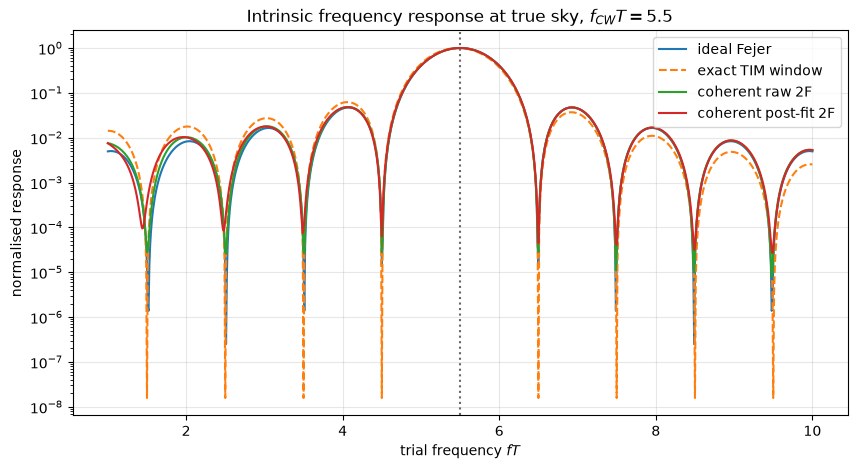

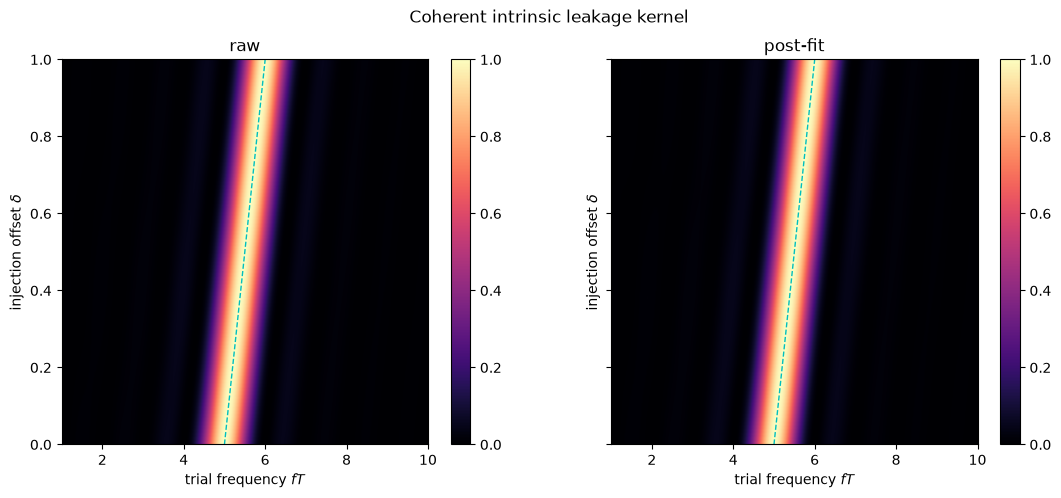

In [7]:
middle = np.flatnonzero(DELTA == 0.5)[0]
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(TRIAL_K, np.maximum(fejer_kernel[middle], 1e-12), label="ideal Fejer")
ax.semilogy(TRIAL_K, np.maximum(window_kernel[middle], 1e-12), "--", label="exact TIM window")
ax.semilogy(TRIAL_K, np.maximum(raw_kernel[middle], 1e-12), label="coherent raw 2F")
ax.semilogy(TRIAL_K, np.maximum(postfit_kernel[middle], 1e-12), label="coherent post-fit 2F")
ax.axvline(5.5, color="0.4", linestyle=":")
ax.set(xlabel=r"trial frequency $fT$", ylabel="normalised response",
       title=r"Intrinsic frequency response at true sky, $f_{CW}T=5.5$")
ax.grid(alpha=0.3); ax.legend(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
extent = [TRIAL_K[0], TRIAL_K[-1], DELTA[0], DELTA[-1]]
for ax, values, title in zip(axes, [raw_kernel, postfit_kernel], ["raw", "post-fit"]):
    image = ax.imshow(values, origin="lower", aspect="auto", extent=extent,
                      vmin=0, vmax=1, cmap="magma")
    ax.plot(5 + DELTA, DELTA, "c--", linewidth=1)
    ax.set(xlabel=r"trial frequency $fT$", ylabel=r"injection offset $\delta$", title=title)
    fig.colorbar(image, ax=ax)
fig.suptitle("Coherent intrinsic leakage kernel"); plt.show()

measured P6/P5 = 0.88554881
theory   P6/P5 = 0.88554881
relative error  = 3.906e-12


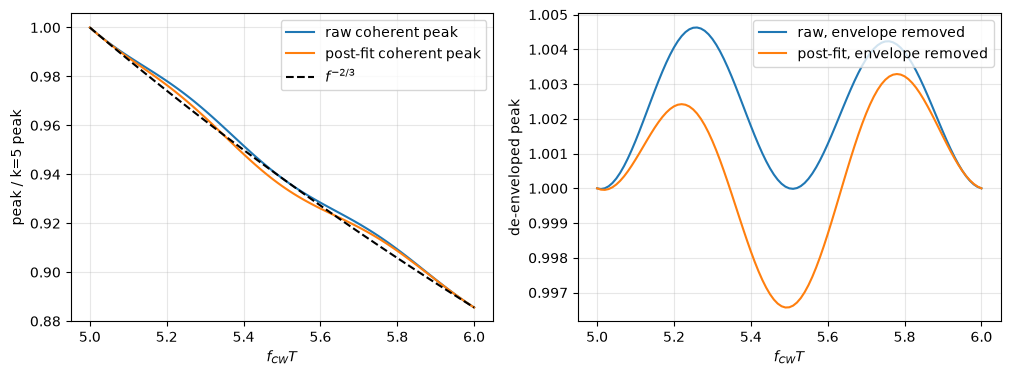

In [8]:
peak_raw = raw_two_f.max(axis=1)
peak_postfit = postfit_two_f.max(axis=1)
envelope = (injection_frequencies / injection_frequencies[0]) ** (-2 / 3)
endpoint_ratio = peak_raw[-1] / peak_raw[0]
theory_ratio = (6 / 5) ** (-2 / 3)
relative_ratio_error = abs(endpoint_ratio / theory_ratio - 1)
print(f"measured P6/P5 = {endpoint_ratio:.8f}")
print(f"theory   P6/P5 = {theory_ratio:.8f}")
print(f"relative error  = {relative_ratio_error:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(5 + DELTA, peak_raw / peak_raw[0], label="raw coherent peak")
axes[0].plot(5 + DELTA, peak_postfit / peak_postfit[0], label="post-fit coherent peak")
axes[0].plot(5 + DELTA, envelope, "k--", label=r"$f^{-2/3}$")
axes[0].set(ylabel="peak / k=5 peak", xlabel=r"$f_{CW}T$")
axes[1].plot(5 + DELTA, peak_raw / envelope / peak_raw[0], label="raw, envelope removed")
axes[1].plot(5 + DELTA, peak_postfit / envelope / peak_postfit[0], label="post-fit, envelope removed")
axes[1].set(ylabel="de-enveloped peak", xlabel=r"$f_{CW}T$")
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.show()

## 4. 全天粗搜、连续精化和偏振稳健性

粗搜在 NSIDE=8 与 $0.05/T$ 网格上进行。每个频率的 sky-max 剖面包含 trials effect；联合最大值随后在 $(f,\theta,\phi)$ 上连续精化。

In [9]:
pixels = np.arange(hp.nside2npix(NSIDE))
sky_theta, sky_phi = hp.pix2ang(NSIDE, pixels)
sky_fp = np.empty((len(pixels), N_PSR))
sky_fc = np.empty_like(sky_fp)
for pixel, (theta, phi) in enumerate(zip(sky_theta, sky_phi)):
    sky_fp[pixel], sky_fc[pixel] = antenna_patterns(ideal_psrs, theta, phi)
blind_frequencies = BLIND_K * fundamental

def refine_joint(data, postfit_data, frequency0, theta0, phi0, postfit=False):
    chosen_data = postfit_data if postfit else data
    operators = projectors if postfit else None
    def objective(parameters):
        k, theta, phi = parameters
        templates = four_amplitude_blocks(
            ideal_psrs, times, k * fundamental, theta, phi % (2 * np.pi)
        )
        if operators is not None:
            templates = apply_blocks(templates, operators)
        value, _, _ = coherent_statistic(chosen_data, templates, SIGMA_S)
        return -value
    result = minimize(
        objective, [frequency0 / fundamental, theta0, phi0], method="Nelder-Mead",
        options={"xatol": 1e-7, "fatol": 1e-7, "maxiter": 600},
    )
    k, theta, phi = result.x
    theta = np.clip(theta, 0, np.pi); phi %= 2 * np.pi
    return k, theta, phi, -result.fun, result.success

def blind_one(injection_frequency, psi, inc, phase0):
    data = signal_blocks(inject(injection_frequency, psi, inc, phase0))
    postfit_data = apply_blocks(data, projectors)
    skymax = np.empty(len(blind_frequencies))
    best_pixels = np.empty(len(blind_frequencies), dtype=int)
    true_profile, _ = coherent_profile(
        ideal_psrs, times, data, blind_frequencies,
        SOURCE_THETA, SOURCE_PHI, SIGMA_S,
    )
    for j, frequency in enumerate(blind_frequencies):
        values = sky_statistic_map(
            ideal_psrs, times, data, frequency,
            sky_theta, sky_phi, SIGMA_S, sky_patterns=(sky_fp, sky_fc),
        )
        best_pixels[j] = np.argmax(values)
        skymax[j] = values[best_pixels[j]]
    j = np.argmax(skymax); pixel = best_pixels[j]
    refined = refine_joint(
        data, postfit_data, blind_frequencies[j],
        sky_theta[pixel], sky_phi[pixel], postfit=False,
    )
    return true_profile, skymax, best_pixels, refined

In [10]:
blind_shape = (len(POLARIZATIONS), len(BLIND_DELTA), len(BLIND_K))
if cache is not None and "blind_skymax" in cache:
    blind_true = cache["blind_true"]
    blind_skymax = cache["blind_skymax"]
    blind_pixels = cache["blind_pixels"]
    refined_results = cache["refined_results"]
    print("Loaded blind-scan arrays from cache")
else:
    blind_true = np.empty(blind_shape)
    blind_skymax = np.empty(blind_shape)
    blind_pixels = np.empty(blind_shape, dtype=int)
    refined_results = np.empty((len(POLARIZATIONS), len(BLIND_DELTA), 5))
    started = time.perf_counter()
    for p, (label, psi, inc, phase0) in enumerate(POLARIZATIONS):
        for d, delta in enumerate(BLIND_DELTA):
            outputs = blind_one((5 + delta) * fundamental, psi, inc, phase0)
            blind_true[p, d], blind_skymax[p, d], blind_pixels[p, d] = outputs[:3]
            refined_results[p, d] = outputs[3]
            print(f"blind {label:9s} delta={delta:.2f}")
    print(f"blind elapsed: {time.perf_counter() - started:.1f} s")

frequency_errors = refined_results[:, :, 0] - (5 + BLIND_DELTA)[None, :]
sky_errors_deg = np.empty(frequency_errors.shape)
coarse_sky_errors_deg = np.empty(frequency_errors.shape)
for p in range(len(POLARIZATIONS)):
    for d in range(len(BLIND_DELTA)):
        sky_errors_deg[p, d] = np.rad2deg(angular_separation(
            refined_results[p, d, 1], refined_results[p, d, 2],
            SOURCE_THETA, SOURCE_PHI,
        ))
        j = np.argmax(blind_skymax[p, d]); pixel = blind_pixels[p, d, j]
        coarse_sky_errors_deg[p, d] = np.rad2deg(angular_separation(
            sky_theta[pixel], sky_phi[pixel], SOURCE_THETA, SOURCE_PHI,
        ))

print("max |refined frequency error| [1/T]:", np.max(np.abs(frequency_errors)))
print("max refined sky error [deg]:", np.max(sky_errors_deg))
print("coarse -> refined median sky error [deg]:",
      np.median(coarse_sky_errors_deg), "->", np.median(sky_errors_deg))
assert np.max(np.abs(frequency_errors)) < 1e-3
assert np.max(sky_errors_deg) < 1.0

blind baseline  delta=0.00


blind baseline  delta=0.25


blind baseline  delta=0.50


blind baseline  delta=0.75


blind baseline  delta=1.00


...

blind generic   delta=0.00


blind generic   delta=0.25


blind generic   delta=0.50


blind generic   delta=0.75


blind generic   delta=1.00
blind elapsed: 55.0 s
max |refined frequency error| [1/T]: 5.4599563981128085e-08
max refined sky error [deg]: 3.6222548091772e-06
coarse -> refined median sky error [deg]: 3.646972916854949 -> 2.000202849784148e-06


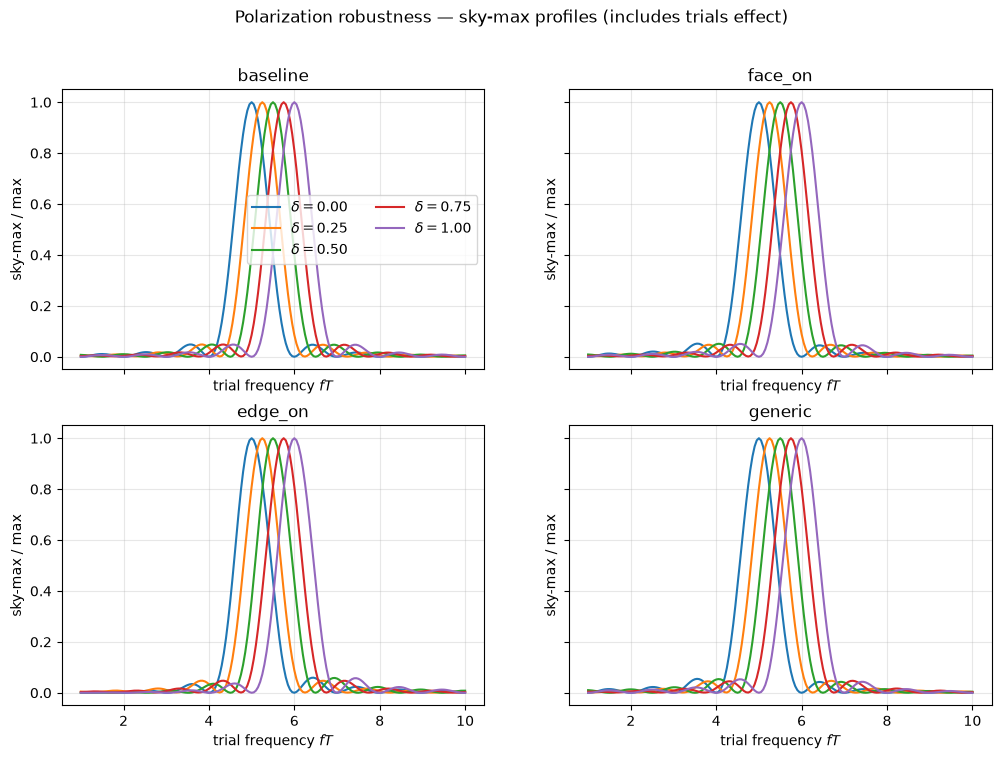

,polarization,delta,frequency error [1/T],coarse sky error [deg],refined sky error [deg]
0,baseline,0.00,-7.464795e-09,3.646973,2.699869e-06
1,baseline,0.25,-5.459956e-08,3.646973,1.207418e-06
2,baseline,0.50,1.131474e-09,3.646973,1.207418e-06
3,baseline,0.75,3.025499e-08,3.646973,8.537736e-07
4,baseline,1.00,-2.042757e-08,3.646973,2.258873e-06
5,face_on,0.00,2.293397e-08,3.646973,1.909096e-06
6,face_on,0.25,-2.626865e-08,3.646973,8.537736e-07
7,face_on,0.50,1.383526e-08,3.646973,2.699869e-06
8,face_on,0.75,3.491839e-08,3.646973,8.537736e-07
9,face_on,1.00,-1.839802e-08,3.646973,1.207418e-06


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for p, (ax, (label, *_)) in enumerate(zip(axes.flat, POLARIZATIONS)):
    for d, delta in enumerate(BLIND_DELTA):
        ax.plot(BLIND_K, blind_skymax[p, d] / blind_skymax[p, d].max(),
                label=rf"$\delta={delta:.2f}$")
    ax.set(title=label, xlabel=r"trial frequency $fT$", ylabel="sky-max / max")
    ax.grid(alpha=0.3)
axes[0, 0].legend(ncol=2)
fig.suptitle("Polarization robustness — sky-max profiles (includes trials effect)")
plt.show()

recovery_rows = []
for p, (label, *_rest) in enumerate(POLARIZATIONS):
    for d, delta in enumerate(BLIND_DELTA):
        recovery_rows.append((label, delta, frequency_errors[p, d],
                              coarse_sky_errors_deg[p, d], sky_errors_deg[p, d]))
display(pd.DataFrame(recovery_rows, columns=[
    "polarization", "delta", "frequency error [1/T]",
    "coarse sky error [deg]", "refined sky error [deg]",
]))

## 5. 与 stochastic pipeline 的归一化对照

若旧的 delta-scan NPZ 存在，只比较归一化形状。PFOS 与 radiometer 使用失配的随机/非偏振模板，因此不把它们解释为 CW 本征核。

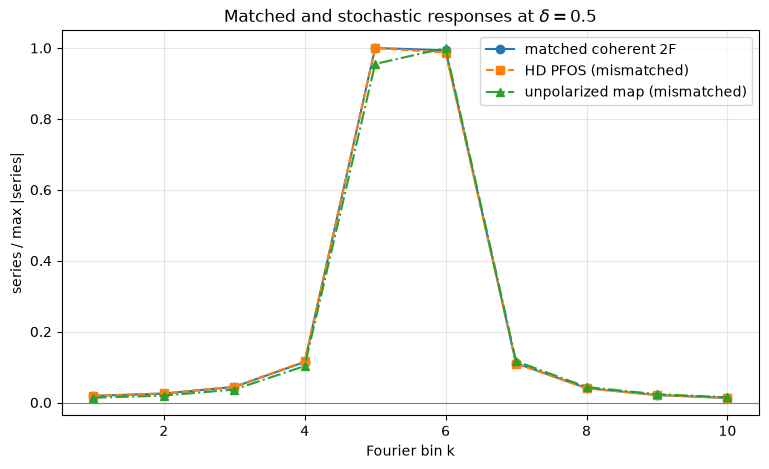

In [12]:
legacy_path = Path("cw_batch_data/delta_scan/k5_delta_0p00_1p00_step_0p01_bins1to10_nside8.npz")
if legacy_path.exists():
    with np.load(legacy_path) as legacy:
        legacy_bins = legacy["scan_bins"]
        legacy_pfos = legacy["pfos_estimator"]
        legacy_map = legacy["source_power"]
    columns = np.array([np.flatnonzero(TRIAL_K == k)[0] for k in legacy_bins])
    coherent_bins = raw_two_f[:, columns]
    selected = np.flatnonzero(DELTA == 0.5)[0]
    fig, ax = plt.subplots(figsize=(9, 5))
    for values, label, marker in [
        (coherent_bins[selected], "matched coherent 2F", "o-"),
        (legacy_pfos[selected], "HD PFOS (mismatched)", "s--"),
        (legacy_map[selected], "unpolarized map (mismatched)", "^-.")]:
        ax.plot(legacy_bins, values / np.max(np.abs(values)), marker, label=label)
    ax.set(xlabel="Fourier bin k", ylabel="series / max |series|",
           title=r"Matched and stochastic responses at $\delta=0.5$")
    ax.axhline(0, color="0.5", linewidth=0.8); ax.grid(alpha=0.3); ax.legend(); plt.show()
else:
    print("Legacy stochastic scan not found; comparison skipped")

In [13]:
np.savez_compressed(
    OUTPUT_PATH,
    format_version=np.array(1), nside=np.array(NSIDE), sigma_s=np.array(SIGMA_S),
    tspan=np.array(tspan), cadence_s=np.array(cadence_s),
    source_theta=np.array(SOURCE_THETA), source_phi=np.array(SOURCE_PHI),
    delta=DELTA, injection_frequencies=injection_frequencies,
    trial_k=TRIAL_K, trial_frequencies=trial_frequencies,
    raw_two_f=raw_two_f, postfit_two_f=postfit_two_f,
    raw_condition=raw_condition, postfit_condition=postfit_condition,
    raw_kernel=raw_kernel, postfit_kernel=postfit_kernel,
    direct_window_power=direct_window_power, exact_window_power=exact_window_power,
    window_kernel=window_kernel, fejer_power=fejer, fejer_kernel=fejer_kernel,
    window_errors=window_errors, peak_raw=peak_raw, peak_postfit=peak_postfit,
    endpoint_ratio=np.array(endpoint_ratio), theory_ratio=np.array(theory_ratio),
    blind_delta=BLIND_DELTA, blind_k=BLIND_K,
    polarization_labels=np.array([x[0] for x in POLARIZATIONS]),
    polarization_parameters=np.array([x[1:] for x in POLARIZATIONS]),
    blind_true=blind_true, blind_skymax=blind_skymax, blind_pixels=blind_pixels,
    refined_results=refined_results, frequency_errors=frequency_errors,
    coarse_sky_errors_deg=coarse_sky_errors_deg, sky_errors_deg=sky_errors_deg,
    timing_ranks=projection_diagnostics.ranks,
    timing_idempotence_error=np.array(projection_diagnostics.idempotence_error),
    timing_orthogonality_error=np.array(projection_diagnostics.orthogonality_error),
)
print(f"Saved {OUTPUT_PATH} ({OUTPUT_PATH.stat().st_size / 1024**2:.2f} MiB)")

Saved cw_batch_data/intrinsic_leakage/cw_matched_scan_v1.npz (4.88 MiB)


## 6. 解释边界

- 本实验测量无 pulsar term、无演化、signal-only Earth-term CW 的 coherent response。
- 当前 par 文件的 active timing design space 只有 `Offset`；post-fit 结果不能外推为完整自旋/天体测量参数拟合。
- Raw 已知天空曲线才是最接近本征有限窗响应的量；post-fit 包含 timing transfer function，sky-max 还包含 trials effect。
- PFOS/radiometer 对照只展示确定性 CW 如何被 stochastic pipeline 解释，不构成 CW 本征泄漏测量。